# Standardizing Data
> This chapter is all about standardizing data. Often a model will make some assumptions about the distribution or scale of your features. Standardization is a way to make your data fit these assumptions and improve the algorithm's performance. This is the Summary of lecture "Preprocessing for Machine Learning in Python", via datacamp.

- toc: true 
- badges: true
- comments: true
- author: Chanseok Kang
- categories: [Python, Datacamp, Machine_Learning]
- image: 

In [ ]:
import pandas as pd
import numpy as np

## Standardizing Data
- Standardization
    - Preprocessing method used to transform continuous data to make it look normally distributed
    - Scikit-learn models assume normally distributed data
        - Log normalization
        - feature Scaling
- When to standardize: models
    - Model in linear space
    - Dataset features have high variance
    - Dataset features are continuous and on different scales
    - Linearity assumptions

### Modeling without normalizing
Let's take a look at what might happen to your model's accuracy if you try to model data without doing some sort of standardization first. Here we have a subset of the wine dataset. One of the columns, `Proline`, has an extremely high variance compared to the other columns. This is an example of where a technique like log normalization would come in handy, which you'll learn about in the next section.

The scikit-learn model training process should be familiar to you at this point, so we won't go too in-depth with it. You already have a k-nearest neighbors model available (`knn`) as well as the `X` and `y` sets you need to fit and score on.

In [4]:
wine = pd.read_csv('./wine_data.csv')
wine.head()

,Wine,Alcohol,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [7]:
X = wine[['Proline', 'Phenols', 'Hue', 'Nonflavanoid.phenols']]
y = wine['Wine'] 

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()

# Split the dataset and labels into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y)

# Fit the k-nearest neighbors model to the training data
knn.fit(X_train, y_train)

# SCore the model on the test data
print(knn.score(X_test, y_test))

0.6666666666666666


/home/webtunixi5/.local/lib/python3.8/site-packages/sklearn/base.py:441: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


## Log normalization
- Applies log transformation
- Natural log using the constant $e$ (2.718)
- Captures relative changes, the magnitude of change, and keeps everything in the positive space

### Checking the variance
Check the variance of the columns in the `wine` dataset.

In [9]:
wine.describe()

,Wine,Alcohol,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,1.938202,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.775035,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,1.000000,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,1.000000,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,2.000000,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,3.000000,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,3.000000,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


The `Proline` column has an extremely high variance.

### Log normalization in Python
Now that we know that the `Proline` column in our wine dataset has a large amount of variance, let's log normalize it.

In [11]:
import numpy as np
# Print out the variance of the Proline column
print(wine['Proline'].var())

# Apply the log normalization function to the Proline column
wine['Proline_log'] = np.log(wine['Proline'])

# Check the variance of the normalized Proline column
print(wine['Proline_log'].var())

99166.71735542436
0.17231366191842012


## Scaling data for feature comparison
- Features on different scales
- Model with linear characteristics
- Center features around 0 and transform to unit variance(1)
- Transforms to approximately normal distribution

### Scaling data - investigating columns
We want to use the `Ash`, `Alcalinity of ash`, and `Magnesium` columns in the `wine` dataset to train a linear model, but it's possible that these columns are all measured in different ways, which would bias a linear model. Using `describe()` to return descriptive statistics about this dataset, which of the following statements are true about the scale of data in these columns?



In [13]:
wine[['Ash', 'Acl', 'Mg']].describe()

,Ash,Acl,Mg
count,178.000000,178.000000,178.000000
mean,2.366517,19.494944,99.741573
std,0.274344,3.339564,14.282484
min,1.360000,10.600000,70.000000
25%,2.210000,17.200000,88.000000
50%,2.360000,19.500000,98.000000
75%,2.557500,21.500000,107.000000
max,3.230000,30.000000,162.000000


#### Scaling data - standardizing columns
Since we know that the `Ash`, `Alcalinity of ash`, and `Magnesium` columns in the `wine` dataset are all on different scales, let's standardize them in a way that allows for use in a linear model.



In [14]:
from sklearn.preprocessing import StandardScaler

# Create the scaler
ss = StandardScaler()

# Take a subset of the DataFrame you want to scale
wine_subset = wine[['Ash', 'Acl', 'Mg']]

print(wine_subset.iloc[:3])

# Apply the scaler to the DataFrame subset
wine_subset_scaled = ss.fit_transform(wine_subset)

print(wine_subset_scaled[:3])

    Ash   Acl   Mg
0  2.43  15.6  127
1  2.14  11.2  100
2  2.67  18.6  101
[[ 0.23205254 -1.16959318  1.91390522]
 [-0.82799632 -2.49084714  0.01814502]
 [ 1.10933436 -0.2687382   0.08835836]]


#### Standardized data and modeling

#### KNN on non-scaled data
Let's first take a look at the accuracy of a K-nearest neighbors model on the `wine` dataset without standardizing the data. The `knn` model as well as the `X` and `y` data and labels sets have been created already. Most of this process of creating models in scikit-learn should look familiar to you.



In [15]:
wine = pd.read_csv('./wine_data.csv')

X = wine.drop('Wine', axis=1)
y = wine['Wine'] 

knn = KNeighborsClassifier()

In [16]:
# Split the dataset and labels into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y)

# Fit the k-nearest neighbors model to the training data
knn.fit(X_train, y_train)

# Score the model on the test data
print(knn.score(X_test, y_test))

0.8


/home/webtunixi5/.local/lib/python3.8/site-packages/sklearn/base.py:441: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


#### KNN on scaled data
The accuracy score on the unscaled wine dataset was decent, but we can likely do better if we scale the dataset. The process is mostly the same as the previous exercise, with the added step of scaling the data. 



In [17]:
knn = KNeighborsClassifier()

# Create the scaling method
ss = StandardScaler()

# Apply the scaling method to the dataset used for modeling
X_scaled = ss.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y)

# Fit the k-nearest neighbors model to the training data.
knn.fit(X_train, y_train)

# Score the model on the test data
print(knn.score(X_test, y_test))

0.9777777777777777


In [21]:
import pandas as pd
df=pd.read_csv('wine_data.csv')
df_scaled = scaler.fit_transform(df)

In [22]:
df_scaled 

array([[-0.5       ,  0.8973384 , -0.10472973, ...,  0.22222222,
         0.92494929,  0.80804954],
       [-0.5       ,  0.11406844, -0.05743243, ...,  0.25185185,
         0.5030426 ,  0.77708978],
       [-0.5       ,  0.08365019,  0.33445946, ...,  0.19259259,
         0.31643002,  1.05572755],
       ...,
       [ 0.5       ,  0.16730038,  1.63175676, ..., -1.11111111,
        -0.98985801,  0.33333333],
       [ 0.5       ,  0.09125475,  0.48986486, ..., -1.08148148,
        -0.94117647,  0.34365325],
       [ 0.5       ,  0.82129278,  1.51013514, ..., -1.05185185,
        -0.95740365, -0.23426213]])

(array([ 1.,  0.,  4.,  7.,  7., 11., 15., 16., 10., 13., 13., 12., 12.,
        14., 17.,  7., 11.,  6.,  0.,  2.]),
 array([-1.53612167, -1.39163498, -1.24714829, -1.1026616 , -0.9581749 ,
        -0.81368821, -0.66920152, -0.52471483, -0.38022814, -0.23574144,
        -0.09125475,  0.05323194,  0.19771863,  0.34220532,  0.48669202,
         0.63117871,  0.7756654 ,  0.92015209,  1.06463878,  1.20912548,
         1.35361217]),
 <BarContainer object of 20 artists>)

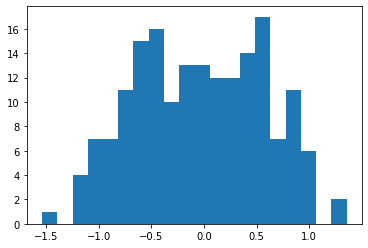

In [23]:
import matplotlib.pyplot as plt
%matplotlib inline
plt.hist(df_scaled[:, 1], bins =20 )

(array([ 8., 10., 15., 44., 23., 10.,  8.,  8.,  5.,  9.,  5.,  6., 10.,
         4.,  4.,  3.,  2.,  1.,  1.,  2.]),
 array([-0.76013514, -0.58918919, -0.41824324, -0.2472973 , -0.07635135,
         0.09459459,  0.26554054,  0.43648649,  0.60743243,  0.77837838,
         0.94932432,  1.12027027,  1.29121622,  1.46216216,  1.63310811,
         1.80405405,  1.975     ,  2.14594595,  2.31689189,  2.48783784,
         2.65878378]),
 <BarContainer object of 20 artists>)

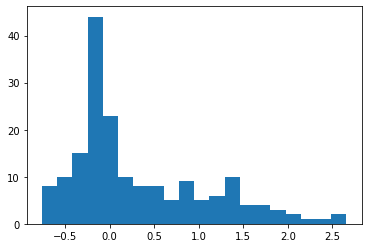

In [24]:
plt.hist(df_scaled[:, 2], bins =20 )


### Robost Scaler

In [20]:
import pandas as pd
from sklearn.preprocessing import RobustScaler
scaler = RobustScaler()
df=pd.read_csv('wine_data.csv')
df_robust_scaler = pd.DataFrame(scaler.fit_transform(df), columns = df.columns)
df_robust_scaler.head()

,Wine,Alcohol,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
0,-0.5,0.897338,-0.104730,0.201439,-0.906977,1.526316,0.420804,0.553892,-0.358209,1.050000,0.318792,0.222222,0.924949,0.808050
1,-0.5,0.114068,-0.057432,-0.633094,-1.930233,0.105263,0.278960,0.374251,-0.477612,-0.392857,-0.104027,0.251852,0.503043,0.777090
2,-0.5,0.083650,0.334459,0.892086,-0.209302,0.157895,0.420804,0.661677,-0.238806,1.792857,0.332215,0.192593,0.316430,1.055728
3,-0.5,1.003802,0.057432,0.402878,-0.627907,0.789474,1.413712,0.811377,-0.597015,0.892857,1.043624,-0.311111,0.543611,1.664603
4,-0.5,0.144487,0.489865,1.467626,0.348837,1.052632,0.420804,0.332335,0.298507,0.378571,-0.124161,0.222222,0.121704,0.126935


(array([59.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0., 71.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0., 48.]),
 array([-0.5 , -0.45, -0.4 , -0.35, -0.3 , -0.25, -0.2 , -0.15, -0.1 ,
        -0.05,  0.  ,  0.05,  0.1 ,  0.15,  0.2 ,  0.25,  0.3 ,  0.35,
         0.4 ,  0.45,  0.5 ]),
 <BarContainer object of 20 artists>)

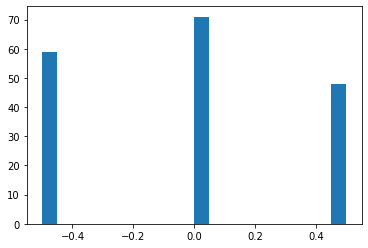

In [32]:
plt.hist(df_robust_scaler['Wine'], bins = 20)

(array([ 1.,  0.,  4.,  7.,  7., 11., 15., 16., 10., 13., 13., 12., 12.,
        14., 17.,  7., 11.,  6.,  0.,  2.]),
 array([-1.53612167, -1.39163498, -1.24714829, -1.1026616 , -0.9581749 ,
        -0.81368821, -0.66920152, -0.52471483, -0.38022814, -0.23574144,
        -0.09125475,  0.05323194,  0.19771863,  0.34220532,  0.48669202,
         0.63117871,  0.7756654 ,  0.92015209,  1.06463878,  1.20912548,
         1.35361217]),
 <BarContainer object of 20 artists>)

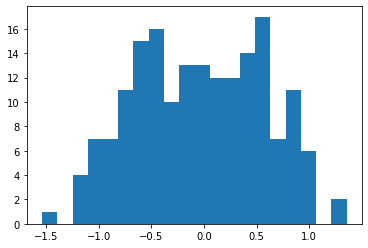

In [27]:
plt.hist(df_robust_scaler['Alcohol'], bins = 20)


### Gaussian Tranformation


In [33]:
##fillnan
df['Proline'] = df['Proline'].fillna(df['Proline'].median())

In [34]:
df.isnull().sum()

Wine                    0
Alcohol                 0
Malic.acid              0
Ash                     0
Acl                     0
Mg                      0
Phenols                 0
Flavanoids              0
Nonflavanoid.phenols    0
Proanth                 0
Color.int               0
Hue                     0
OD                      0
Proline                 0
dtype: int64

In [35]:
import scipy.stats as stat
import pylab

In [38]:
## If you want to check whether feature is gaussian or normal distribution
## Q-Q plot
def plot_data(df, feature):
    plt.figure(figsize= (10,6))
    plt.subplot(1,2,1)
    df[feature].hist()
    plt.subplot(1,2,2)     ## subplot(row, coulmn, index)
    stat.probplot(df[feature],dist = 'norm', plot = pylab)
    plt.show() 

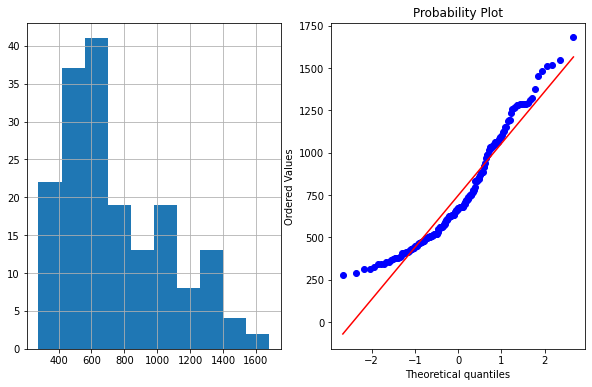

In [39]:
plot_data(df,'Proline')

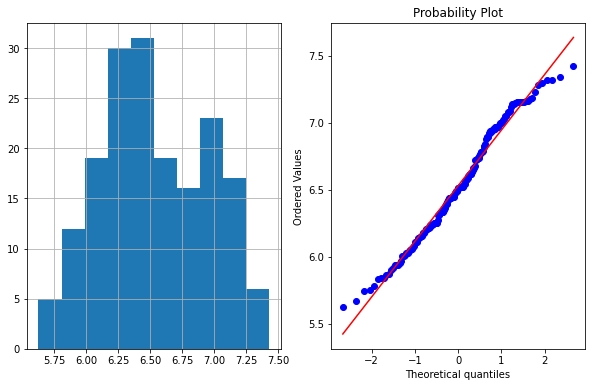

In [41]:
#Logarithmic Transformation
import numpy as np
df['Proline_log']= np.log(df['Proline'])
plot_data(df, 'Proline_log')

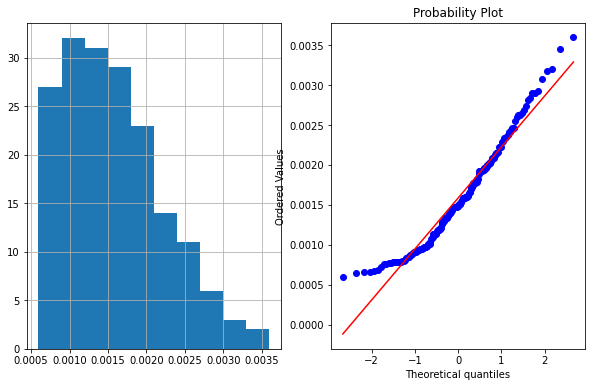

In [42]:
#Reciprocal Transformation
df['Proline_reciprocal'] = 1/df.Proline
plot_data(df, 'Proline_reciprocal')

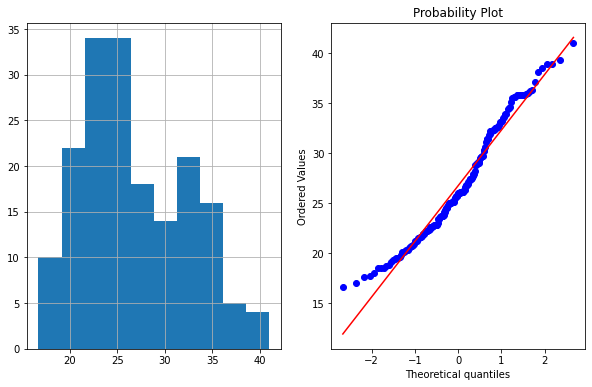

In [43]:
#Square Root Transformation
df['Proline_square'] = df.Proline**(1/2)
plot_data(df, "Proline_square")

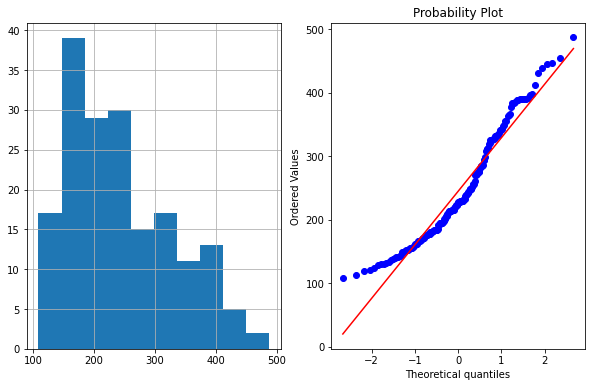

In [44]:
#Exponential Transformation

df['Proline_exponential'] = df.Proline**(1/1.2)
plot_data(df, 'Proline_exponential')

##### Box Cox Transformation


In [46]:
df['Proline_Boxcox'], parameters = stat.boxcox(df['Proline'])


In [47]:
print(parameters)


-0.10330889162354384


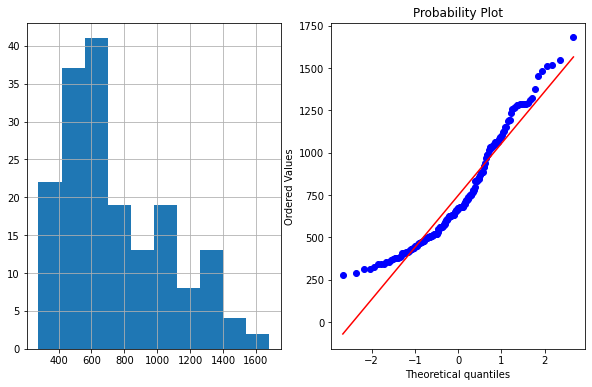

In [48]:
plot_data(df,"Proline")


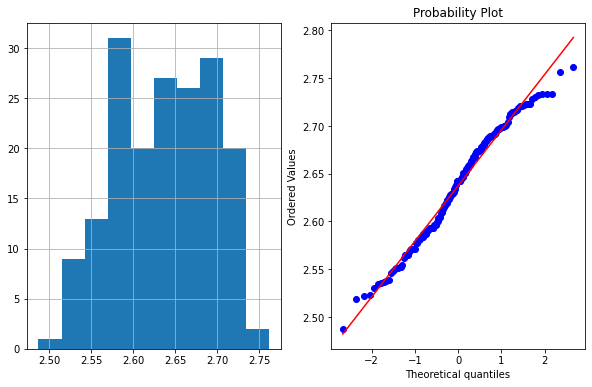

In [49]:
### for Fare Log transform
df['Alcohol_log'] = np.log1p(df['Alcohol'])
plot_data(df, 'Alcohol_log')

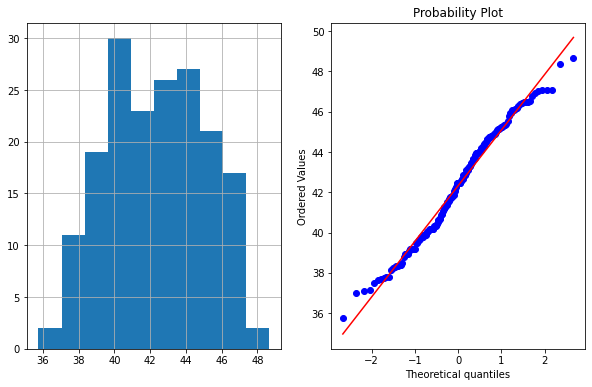

In [51]:
df['Alcohol_Boxcox'],parameters = stat.boxcox(df['Alcohol']+1)  ## we were getting -1 value so we added 1
plot_data(df,"Alcohol_Boxcox")